This notebook tests the output of the transcript-based segmentation tool Proseg for imaging-based spatial trasncriptomics data. 

Xenium data for SN222R1-Ma1Fd2-1U1 has been processed with Proseg, and this notebook demonstrates the UMAP and clustering results before and after Proseg.

Since Spatialdata and rapids-singlecell has Dask-related dependency issues, so we break the workflow into two parts:
1. Use the spatialdata environment to read in the spatialdata object, extract AnnData, and save
2. Use the rapids-singlecell environment to read the AnnData and perform normalization, HVG selection, PCA, UMAP, and clustering.

# Part 1: Load spatialdata object, export AnnData for downstream processing

In [2]:
import scanpy as sc
import spatialdata as sd
import spatialdata_io as sdio


## Original Xenium data (default Xenium segmentation)

In [3]:

sn222 = sdio.xenium("output-XETG00523__0034248__SN222R1-Ma1Fd2-1U1__20250523__192829")

INFO     reading output-XETG00523__0034248__SN222R1-Ma1Fd2-1U1__20250523__192829/cell_feature_matrix.h5            


/data/chouw/tmp/ipykernel_240116/744033346.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sn222 = sdio.xenium("output-XETG00523__0034248__SN222R1-Ma1Fd2-1U1__20250523__192829")
/data/chouw/Software/miniforge3/envs/spatialdata-pytorch/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
xe_adata = sn222['table'].copy()

# Filter out snv probes
probes_to_keep = [x for x in xe_adata.var_names if '_WT' not in x and '_ALT' not in x]
xe_adata = xe_adata[:, probes_to_keep].copy()
xe_adata.write_h5ad('SN222_original.h5ad')

## SN222R1 processed by Proseg

In [5]:
sdata = sd.read_zarr('proseg-output.zarr')

In [6]:
proseg_adata = sdata['table'].copy()

# Filter out snv probes
probes_to_keep = [x for x in proseg_adata.var_names if '_WT' not in x and '_ALT' not in x]
proseg_adata = proseg_adata[:, probes_to_keep].copy()
proseg_adata.write_h5ad('SN222_proseg.h5ad')


# Part 2: GPU-accelerated processing

In [1]:
import rapids_singlecell as rsc
import scanpy as sc
import cupyx as cpx

/data/chouw/Software/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
# Specify the GPU index you want to use (e.g., "1", "2", or "3")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [3]:
# Define standard processing steps
def xenium_processing(adata):
    rsc.get.anndata_to_GPU(adata)
    rsc.pp.filter_cells(adata, min_counts = 5)
    rsc.pp.normalize_total(adata)
    rsc.pp.log1p(adata)
    rsc.pp.highly_variable_genes(adata, flavor="seurat_v3")
    rsc.pp.pca(adata, n_comps = 30)
    rsc.pp.neighbors(adata, n_pcs = 30, n_neighbors = 30, metric = "cosine")
    rsc.tl.umap(adata, min_dist = 0.3)
    rsc.tl.leiden(adata, resolution = 0.8)
    return adata



## Original Xenium data

In [4]:
xe_adata = sc.read_h5ad('SN222_original.h5ad')

In [5]:
xe_adata = xenium_processing(xe_adata)

filtered out 4969 cells that have less than 5 counts


/data/chouw/Software/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/rapids_singlecell/preprocessing/_hvg.py:534: UserWarning: `flavor='seurat_v3'` expects `n_top_genes`  to be defined, defaulting to 2000 HVGs
  warnings.warn(
/data/chouw/Software/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/rapids_singlecell/preprocessing/_hvg.py:549: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


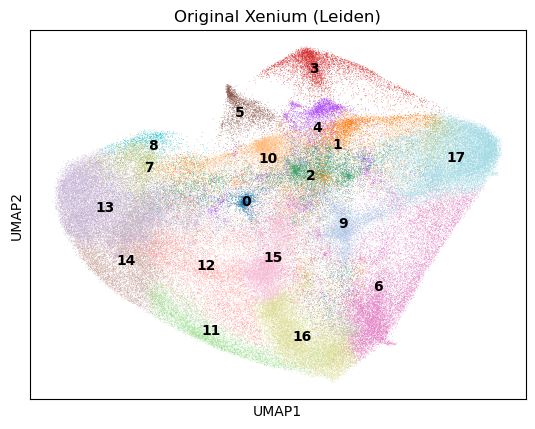

In [13]:
sc.pl.umap(xe_adata, color = 'leiden', legend_loc = 'on data', title = 'Original Xenium (Leiden)')

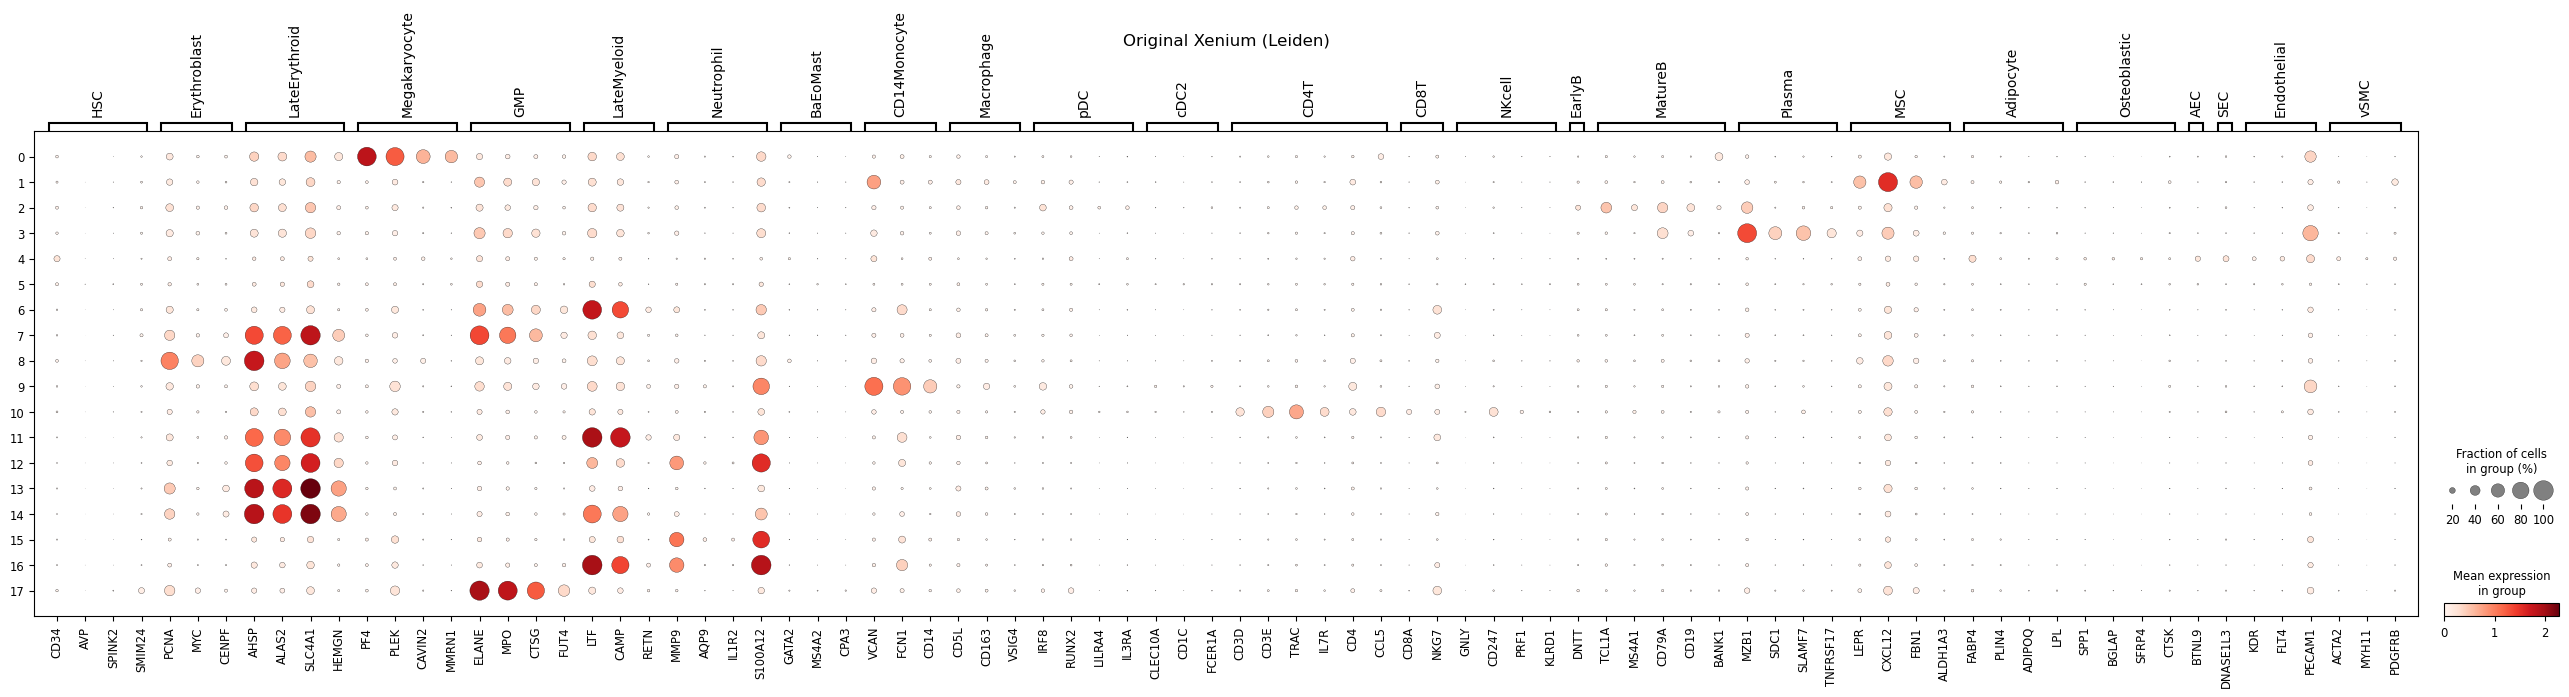

In [52]:
all_markers = {
    "HSC": ["CD34", "AVP", "SPINK2", "SMIM24"],
    "Erythroblast": ["PCNA", "MYC", "CENPF"],  # "PARP1", "GATA1", 
    "LateErythroid": ["AHSP", "ALAS2", "SLC4A1", "HEMGN"],
    "Megakaryocyte": ["PF4", "PLEK", "CAVIN2", "MMRN1"],
    "GMP": ["ELANE", "MPO", "CTSG", "FUT4"],
    "LateMyeloid": ["LTF", "CAMP", "RETN"],
    "Neutrophil": ["MMP9", "AQP9", "IL1R2", "S100A12"],  # "ITGAM", 
    "BaEoMast": ["GATA2", "MS4A2", "CPA3"],  # "MS4A3", 
    "CD14Monocyte": ["VCAN", "FCN1", "CD14"],
    "Macrophage": ["CD5L", "CD163", "VSIG4"],
    "pDC": ["IRF8", "RUNX2", "LILRA4", "IL3RA"],
    "cDC2": ["CLEC10A", "CD1C", "FCER1A"],
    "CD4T": ["CD3D", "CD3E", "TRAC", "IL7R", "CD4", "CCL5"],
    "CD8T": ["CD8A", "NKG7"],
    "NKcell": ["GNLY", "CD247", "PRF1", "KLRD1"],
    "EarlyB": ["DNTT"],  # "IGLL1", "VPREB1"
    "MatureB": ["TCL1A", "MS4A1", "CD79A", "CD19", "BANK1"],
    "Plasma": ["MZB1", "SDC1", "SLAMF7", "TNFRSF17"],
    "MSC": ["LEPR", "CXCL12", "FBN1", "ALDH1A3"],
    "Adipocyte": ["FABP4", "PLIN4", "ADIPOQ", "LPL"],
    "Osteoblastic": ["SPP1", "BGLAP", "SFRP4", "CTSK"],
    "AEC": ["BTNL9"],
    "SEC": ["DNASE1L3"],
    "Endothelial": ["KDR", "FLT4", "PECAM1"],  # "ENG"
    "vSMC": ["ACTA2", "MYH11", "PDGFRB"]
}
#rsc.get.anndata_to_CPU(xe_adata)
sc.pl.dotplot(xe_adata, all_markers, groupby='leiden', title = 'Original Xenium (Leiden)')

## Proseg data

filtered out 8316 cells that have less than 5 counts


/data/chouw/Software/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/rapids_singlecell/preprocessing/_hvg.py:534: UserWarning: `flavor='seurat_v3'` expects `n_top_genes`  to be defined, defaulting to 2000 HVGs
  warnings.warn(
/data/chouw/Software/miniforge3/envs/rapids_singlecell/lib/python3.13/site-packages/rapids_singlecell/preprocessing/_hvg.py:549: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


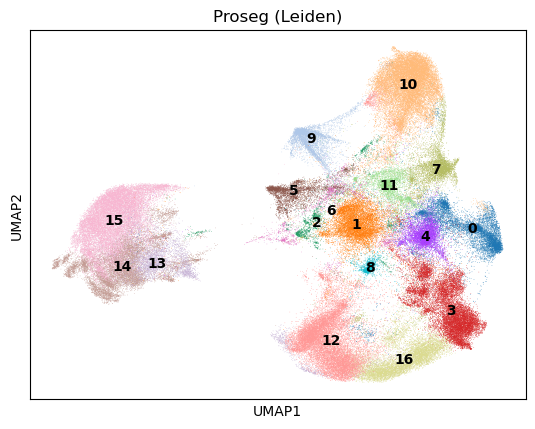

In [14]:
proseg_adata = sc.read_h5ad('SN222_proseg.h5ad')
proseg_adata.X = proseg_adata.X.astype('float32')
proseg_adata = xenium_processing(proseg_adata)
sc.pl.umap(proseg_adata, color = 'leiden', legend_loc = 'on data', title = 'Proseg (Leiden)')

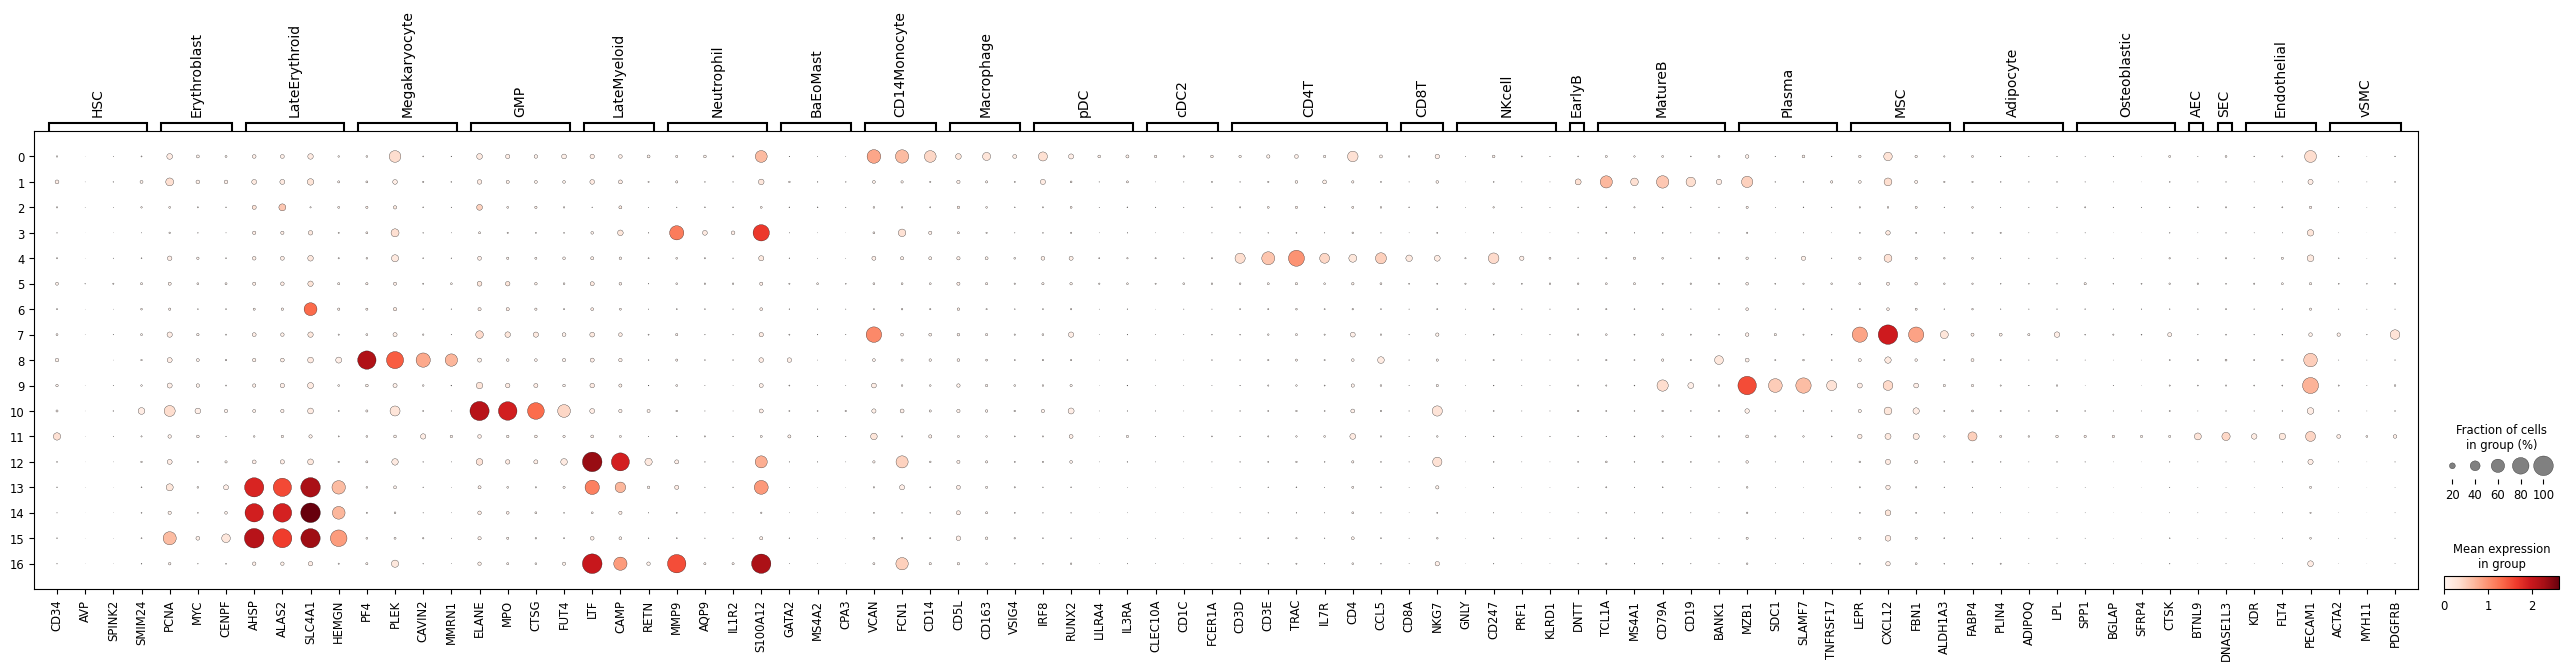

In [29]:
all_markers = {
    "HSC": ["CD34", "AVP", "SPINK2", "SMIM24"],
    "Erythroblast": ["PCNA", "MYC", "CENPF"],  # "PARP1", "GATA1", 
    "LateErythroid": ["AHSP", "ALAS2", "SLC4A1", "HEMGN"],
    "Megakaryocyte": ["PF4", "PLEK", "CAVIN2", "MMRN1"],
    "GMP": ["ELANE", "MPO", "CTSG", "FUT4"],
    "LateMyeloid": ["LTF", "CAMP", "RETN"],
    "Neutrophil": ["MMP9", "AQP9", "IL1R2", "S100A12"],  # "ITGAM", 
    "BaEoMast": ["GATA2", "MS4A2", "CPA3"],  # "MS4A3", 
    "CD14Monocyte": ["VCAN", "FCN1", "CD14"],
    "Macrophage": ["CD5L", "CD163", "VSIG4"],
    "pDC": ["IRF8", "RUNX2", "LILRA4", "IL3RA"],
    "cDC2": ["CLEC10A", "CD1C", "FCER1A"],
    "CD4T": ["CD3D", "CD3E", "TRAC", "IL7R", "CD4", "CCL5"],
    "CD8T": ["CD8A", "NKG7"],
    "NKcell": ["GNLY", "CD247", "PRF1", "KLRD1"],
    "EarlyB": ["DNTT"],  # "IGLL1", "VPREB1"
    "MatureB": ["TCL1A", "MS4A1", "CD79A", "CD19", "BANK1"],
    "Plasma": ["MZB1", "SDC1", "SLAMF7", "TNFRSF17"],
    "MSC": ["LEPR", "CXCL12", "FBN1", "ALDH1A3"],
    "Adipocyte": ["FABP4", "PLIN4", "ADIPOQ", "LPL"],
    "Osteoblastic": ["SPP1", "BGLAP", "SFRP4", "CTSK"],
    "AEC": ["BTNL9"],
    "SEC": ["DNASE1L3"],
    "Endothelial": ["KDR", "FLT4", "PECAM1"],  # "ENG"
    "vSMC": ["ACTA2", "MYH11", "PDGFRB"]
}
rsc.get.anndata_to_CPU(proseg_adata)
sc.pl.dotplot(proseg_adata, all_markers, groupby='leiden')


In [16]:
rsc.tl.rank_genes_groups_logreg(proseg_adata, 'leiden')

[2025-12-17 22:51:52.585] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)


In [26]:
# Loop through every leiden cluster and get the top 10 markers
import pandas as pd
df = pd.DataFrame()
for i in proseg_adata.obs['leiden'].unique():
    top_markers = sc.get.rank_genes_groups_df(proseg_adata, group = i).head(10)
    top_markers['cluster'] = i
    df = pd.concat([df, top_markers])





In [51]:
df[df['cluster'] == '11']

,names,scores,cluster
0,GPC3,1.246829,11
1,PECAM1,0.871553,11
2,PPY,0.862799,11
3,CD63,0.809677,11
4,GNAS,0.790476,11
5,MMRN2,0.773506,11
6,NPDC1,0.749993,11
7,DNAAF1,0.705377,11
8,THBS2,0.701035,11
9,STC2,0.678873,11
